In [2]:
import qcodes

import matplotlib.pyplot as plt
from matplotlib import cm, colors

import numpy as np
import pandas as pd
import time

from scipy.optimize import curve_fit
import pathlib

from pyCircFit_main import *

In [3]:
def circle_fit(freq,re,im,power,plotResults=True):

    # adapted from Kaushal's code to circle fit S21 data 
    amp_array = re+1j*im
    phase = np.unwrap(np.angle(amp_array))

    phase_corr=False
    if phase_corr:
        phase = np.unwrap(np.angle(amp_array))
        line_delay = (phase[0]-phase[-1])/(freq[0]-freq[-1])
        phase_corr_array = -phase[0]-line_delay*(freq-freq[0])
        amp_corr_array = amp_array * np.exp(1j*phase_corr_array)
        q_corr = np.imag(amp_corr_array)
        i_corr = np.real(amp_corr_array)
        mag_corr = np.sqrt(q_corr**2 + i_corr**2)
        phase_correct = np.unwrap(np.angle(amp_corr_array))
        plt.figure(11)
        plt.scatter(freq,10*np.log10(mag_corr))
        plt.figure(22)
        plt.scatter(freq,phase_correct)
        plt.figure(33)
        plt.scatter(i_corr,q_corr)
        plt.gca().set_aspect('equal')
        cresults = circlefit(freq/1e6, i_corr, q_corr,fittype='hanger', plotlabel='test', plot_detail = False, print_results=False, show_plots=False, fitQscl=1, fano = True)
        fit_data = S21_hanger(cresults['a'], cresults['alpha'], 0, cresults['fr'], 
                            cresults['Qtot'], cresults['Qc'], cresults['phi'], freq/1e6)
    
    i_corr = re
    q_corr = im
    cresults = circlefit(freq/1e6, re, im, fittype='hanger', plotlabel='test', plot_detail = False, print_results=False, show_plots=False, fitQscl=1, fano = True)
    fit_data = S21_hanger(cresults['a'], cresults['alpha'], 0, cresults['fr'], 
                            cresults['Qtot'], cresults['Qc'], cresults['phi'], freq/1e6)
        
        # from Kaushal's code to calculate photon number 
    h = 6.63*1e-34
    q = np.abs(cresults['Qtot'])
    q_err = cresults['Qtot_stderr']
    qc = cresults['Qc']
    qc_err = np.abs(cresults['Qc_stderr'])
    qi = cresults['Qi']
    qi_err = np.abs(cresults['Qi_stderr'])
    f = cresults['fr']*1e6
    f_err = cresults['fr_stderr']
    a = cresults['a']

    # plotting results 
    if (plotResults):
        ## from Kaushal's code to plot circle fit
        plt.figure(figsize=(6,6))
        plt.scatter(i_corr, q_corr, label= 'IQ data', s=12)
        plt.plot(np.real(fit_data), np.imag(fit_data), label='IQ fit', linewidth=6, color='C2')
        plt.legend(fontsize=14, loc='upper right')
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.xlabel('I (a.u.)', fontsize=12)
        plt.ylabel('Q (a.u.)', fontsize=12)
        plt.title(r'$\bf{f}$'+f' = {np.round(cresults["fr"]*1e-3,4)} GHz' + r'$\pm $' + 
            f'{np.round(cresults['fr_stderr']*1e3,1)} KHz,' + r'$\bf{Q}_i$' + f' = {np.abs(np.round(cresults["Qi"],1))}' + r'$\pm $' + 
            f'{np.round(cresults['Qi_stderr'],1)},'  + r'$\bf{Q}_c$' + f' = {np.abs(np.round(cresults["Qc"],1))}' + r'$\pm $' + 
            f'{np.round(cresults['Qc_stderr'],1)}', fontsize=12)
        plt.gca().set_aspect('equal')
        plt.show()
    
    #returns results for quantities
    return q,q_err,qc,qc_err,qi,qi_err,f,f_err,a

In [ ]:
# Calculate expected Q's from derived coupling capacitance!

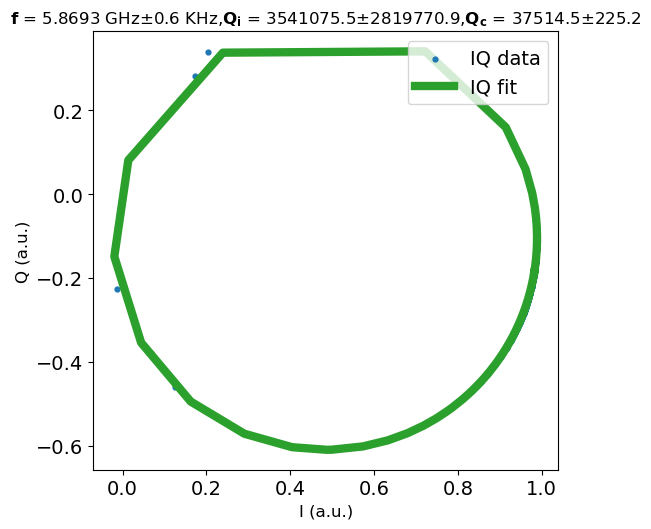

(np.float64(37928.9207434359),
 np.float64(227.3600016441638),
 np.float64(37514.50722373155),
 np.float64(225.21173665771585),
 np.float64(-3541075.5083851754),
 np.float64(2819770.8812526325),
 np.float64(5869291629.1720915),
 np.float64(0.0006337902651380973),
 np.float64(0.9996576437113761))

In [63]:
filepath = r"C:\Users\emmag\OneDrive\Documents\2d-sensing\2d-sensing\src\analysis\lambda2_8500um_50um_coupling.csv"
df = pd.read_csv(filepath)
re = np.array(df['RE[S12]'])
im = np.array(df['IM[S12]'])
freq = 1e9*np.array(df['Frequency (GHz)'])
circle_fit(freq,re,im,power=-80)

1.8355946186552295e-15


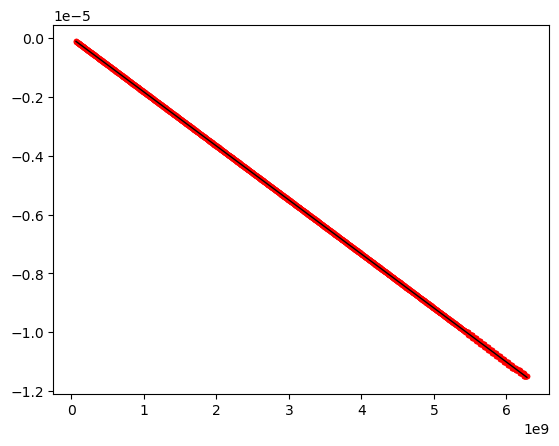

In [64]:
filename = r"C:\Users\emmag\OneDrive\Documents\2d-sensing\2d-sensing\src\analysis\lambda2_50um_coupling_15um_turnradius.csv"
df = pd.read_csv(filename)
y_im = np.array(df['IM[Y12]'])
freq = 2*np.pi*1e9*np.array(df['Frequency (GHz)'])
m,b = np.polyfit(freq,y_im,1)
plt.plot(freq,y_im,linestyle='',marker='.',color='red')
plt.plot(freq,m*freq+b,color='k',linewidth=1)
print(np.abs(m))

In [52]:
# Ok, now estimate coupling Q's from this capacitance to the resonator!
def est_coupling_q(f0,z0,Cc,R):
    w0 = 2*np.pi*f0
    qc = np.pi/(z0*R*(w0*Cc)**2)
    return qc

In [67]:
qc = est_coupling_q(f0=5.869e9,z0=51,Cc=m,R=50)
print("Estimated Qc: ",qc)

Estimated Qc:  268885.9964930195
